# Practice 1: Part-of-Speech (POS) Tagger

This notebook implements a neural Part-of-Speech (POS) tagger using LSTMs.

The goal is to load a corpus in CoNLL-U format, process it, build a model in Keras to tag it, train it, and finally, use it to predict tags on new sentences.

---

## 1 Loading the Data

The first step is to read the data from the `CoNLL-U` file format.

This cell defines the `load_conllu_data` function, which is the heart of our data preprocessing.

* **Purpose**: It reads a `.conllu` file and transforms it into two parallel lists: one of sentences (lists of words) and another of tags (lists of UPOS tags).
* **Processing Logic**:
    * It iterates over each line in the file.
    * **Ignores Comments**: If the line starts with `#`, it's ignored.
    * **Handles Sentence Boundaries**: A blank line marks the end of a sentence. At this point, the accumulated `current_sentence` and `current_tags` are appended to the main lists.
    * **Ignores Special Tokens**: The code ignores "multiword" tokens (e.g., `19-20` "don't") and "empty nodes" (which have a dot in the ID, e.g., `1.1`).
    * **Extracts Data**: For a normal token line, it splits the line by the tab character `\t`. It then extracts:
        * `word` (FORM) from field 1 (index `[1]`).
        * `pos_tag` (UPOS) from field 3 (index `[3]`).
    * These are appended to the `current_` lists.

In [1]:
def load_conllu_data(filepath):
    """
    Loads and processes a CoNLL-U file, extracting sentences and their UPOS tags.
    """
    sentences = []
    tags = []
    current_sentence = []
    current_tags = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            #Ignore comments and empty lines that are not sentence separators
            if line.startswith('#'):
                continue
            
            # Blank line: indicates the end of a sentence
            elif line == '':
                if current_sentence:
                    sentences.append(current_sentence)
                    tags.append(current_tags)
                    current_sentence = []
                    current_tags = []
            
            #  Process a word line
            else:
                fields = line.split('\t')
                
                # Ignore multiword tokens 
                if '-' in fields[0] or '.' in fields[0]:
                    continue

                # Extract the word (FORM, index 1) and the PoS tag (UPOS, index 3)
                word = fields[1]
                pos_tag = fields[3]
                
                current_sentence.append(word)
                current_tags.append(pos_tag)

    if current_sentence:
        sentences.append(current_sentence)
        tags.append(current_tags)

    return sentences, tags

### Language Configuration and Loading

This cell prepares the notebook to be reusable for different languages.

* **`LANGUAGE_CONFIG`**: A dictionary that maps a language code ('en', 'es', 'pt', 'fa') to the paths of its respective `train`, `dev`, and `test` files. 
* **`SELECTED_LANGUAGE = 'fa'`**: This is where we select the language the rest of the notebook will work with. In this case, Persian (Farsi) has been chosen.
* **Data Loading**: The code uses the `SELECTED_LANGUAGE` variable to get the correct paths from the `LANGUAGE_CONFIG` dictionary and then calls the `load_conllu_data` function three times to load the training, development, and test sets.
* **Output**: The final `print` statements verify that the data has been loaded, showing the total number of sentences in each set and an example of the first sentence.

In [2]:
LANGUAGE_CONFIG = {
    'en': {
        'train': 'English/en_ewt-ud-train.conllu',
        'dev': 'English/en_ewt-ud-dev.conllu',
        'test': 'English/en_ewt-ud-test.conllu'
    },
    'es': {
        'train': 'Spanish/es_ancora-ud-train.conllu',
        'dev': 'Spanish/es_ancora-ud-dev.conllu',
        'test': 'Spanish/es_ancora-ud-test.conllu'
    },
    'pt': {
        'train': 'Portuguese/pt_porttinari-ud-train.conllu',
        'dev': 'Portuguese/pt_porttinari-ud-dev.conllu',
        'test': 'Portuguese/pt_porttinari-ud-test.conllu'
    },
    'fa': {
        'train': 'Persian/fa_perdt-ud-train.conllu',
        'dev': 'Persian/fa_perdt-ud-dev.conllu',
        'test': 'Persian/fa_perdt-ud-test.conllu'
    }
}

# ==================================================================
# SELECT LANGUAGE HERE
# ==================================================================
SELECTED_LANGUAGE = 'en'

# Get the paths for the selected language
try:
    paths = LANGUAGE_CONFIG[SELECTED_LANGUAGE]
    print(f"--- Model for: '{SELECTED_LANGUAGE}' ---")

    # --- # Load the data using the selected paths ---
    train_sents, train_tags = load_conllu_data(paths['train'])
    dev_sents, dev_tags = load_conllu_data(paths['dev'])
    test_sents, test_tags = load_conllu_data(paths['test'])
    
    print("\nLoading complete")
    print(f"Sentences for training: {len(train_sents)} example train sents {train_sents[8]}")
    print(f"tags: {train_tags[8]}")
    print(f"Sentences for dev: {len(dev_sents)} example dev sents {dev_sents[0]}")
    print(f"Sentences for test: {len(test_sents)} example test sents {test_sents[0]}")
    
except KeyError:
    print(f"Error: The language '{SELECTED_LANGUAGE}' is not in LANGUAGE_CONFIG.")
    exit()

--- Model for: 'en' ---

Loading complete
Sentences for training: 12544 example train sents ['Although', 'the', 'announcement', 'was', 'probably', 'made', 'to', 'show', 'progress', 'in', 'identifying', 'and', 'breaking', 'up', 'terror', 'cells', ',', 'I', 'do', "n't", 'find', 'the', 'news', 'that', 'the', 'Baathists', 'continue', 'to', 'penetrate', 'the', 'Iraqi', 'government', 'very', 'hopeful', '.']
tags: ['SCONJ', 'DET', 'NOUN', 'AUX', 'ADV', 'VERB', 'PART', 'VERB', 'NOUN', 'SCONJ', 'VERB', 'CCONJ', 'VERB', 'ADP', 'NOUN', 'NOUN', 'PUNCT', 'PRON', 'AUX', 'PART', 'VERB', 'DET', 'NOUN', 'SCONJ', 'DET', 'PROPN', 'VERB', 'PART', 'VERB', 'DET', 'ADJ', 'NOUN', 'ADV', 'ADJ', 'PUNCT']
Sentences for dev: 2001 example dev sents ['From', 'the', 'AP', 'comes', 'this', 'story', ':']
Sentences for test: 2077 example test sents ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?']


## 2. Text Vectorization: Creating the Dictionaries

The first step in preparing the data for the LSTM model is to convert our text-based sentences and tags into numerical sequences. Neural networks can only process numbers, so we need a consistent way to map each word and each tag to a unique integer ID.

For this task, we'll use Keras's modern `TextVectorization` layer. We will create two separate instances of this layer: one for the input words (`word_vectorizer`) and one for the output tags (`tag_vectorizer`).

The process involves two main stages:
1.  **Configuration**: We initialize the `TextVectorization` layer with `output_mode='int'` to ensure it produces sequences of integer IDs (e.g., "Google is nice" -> `[2, 3, 42]`). We also set `output_sequence_length=128` to enforce that all sequences are padded or truncated to a fixed length, which is a requirement for the model.
2.  **Adaptation**: We then call the `.adapt()` method on our training data. This step builds the internal vocabulary for each vectorizer. It analyzes all the words (or tags) in the training set and assigns a unique integer to each one. This ensures our "dictionaries" are based only on the data the model is allowed to learn from.


#### Code Explanation: Vectorization and Adaptation

This cell implements the vectorization process described above.

* **`MAX_LEN = 128`**: This global constant defines the maximum sentence length. This decision is based on the assignment instructions, which allow ignoring or truncating longer sentences to simplify processing.
* **`create_and_adapt_vectorizer`**: This helper function encapsulates the process of creating a vectorizer, setting its configuration (`output_mode`, `output_sequence_length`, `standardize`), and adapting it to the data.
* **`standardize` Decisions**:
    * `word_vectorizer`: Uses `standardize="lower"`. This converts all words to lowercase, reducing the vocabulary size (e.g., "Google" and "google" map to the same ID). It also keeps punctuation.
    * `tags_vectorizer`: Uses `standardize='lower_and_strip_punctuation'`. This is an unusual choice, as UPOS tags are canonically uppercase (e.g., 'NOUN', 'VERB'). However, the code is consistent: it creates a vocabulary of lowercase tags (as seen in the output `tags_vectorizer ['', '[UNK]', 'noun', ...]`), and the model will learn to predict these lowercase tags.
* **`adapt()`**: The `adapt` method is called *only* on the `train_sents` and `train_tags` data. This is crucial to prevent "data leakage", the model must not know about any words or tags that only appear in the development or test sets.
* **Flattening and Transformation**:
    * The `TextVectorization` layer expects a flat list of strings, not a list of lists. Therefore, the code "flattens" the sentences by joining the words with spaces (e.g., `['Google', 'is']` -> `'Google is'`).
    * Finally, the adapted vectorizers are called as functions to transform all datasets (train, dev, test), converting them from lists of strings to numerical ID tensors (`X_train`, `y_train`, etc.).

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

MAX_LEN = 128

def create_and_adapt_vectorizer(sentences, standardize, max_len=MAX_LEN):

    vectorizer = TextVectorization(
        output_mode='int',
        output_sequence_length=max_len,
        standardize=standardize
    )

    print("\nSentences before flat", sentences[0])
    sentences_flat = [' '.join(sentence) for sentence in sentences]
    print("\nSentence after flat", sentences_flat[0])
    
    vectorizer.adapt(sentences_flat)
    
    vocab_size = len(vectorizer.get_vocabulary())
    
    print(f"\nAdaptation complete. Vocabulary size: {vocab_size}")
    
    return vectorizer, vocab_size


# Pass 'standardize="lower"' to the word vectorizer
word_vectorizer, WORD_VOCAB_SIZE = create_and_adapt_vectorizer(train_sents, standardize="lower")

# The tag vectorizer uses 'lower_and_strip_punctuation'
tags_vectorizer, TAGS_VOCAB_SIZE = create_and_adapt_vectorizer(train_tags, standardize='lower_and_strip_punctuation')

# Get the vocabulary string list
tags_vocab_list = tags_vectorizer.get_vocabulary()
print("tags_vectorizer",tags_vocab_list)

print(f"\nWe have successfully created a vectorizer with a vocabulary of {WORD_VOCAB_SIZE} words.")

print(f"\nWe have successfully created a vectorizer with a vocabulary of {TAGS_VOCAB_SIZE} tags.")

print("Vectorizing all data sets...")


# --- 1. Flatten the data from list of lists to list of strings ---
# The vectorizer layers expect a flat list of strings as input.
train_sents_flat = [' '.join(sentence) for sentence in train_sents]
train_tags_flat = [' '.join(tag_list) for tag_list in train_tags]

dev_sents_flat = [' '.join(sentence) for sentence in dev_sents]
dev_tags_flat = [' '.join(tag_list) for tag_list in dev_tags]

test_sents_flat = [' '.join(sentence) for sentence in test_sents]
test_tags_flat = [' '.join(tag_list) for tag_list in test_tags]


# --- 2. Use the vectorizers to transform the flattened data ---
# Now we call the vectorizers with the correct input format.
X_train = word_vectorizer(train_sents_flat)
y_train = tags_vectorizer(train_tags_flat)

X_dev = word_vectorizer(dev_sents_flat)
y_dev = tags_vectorizer(dev_tags_flat)

X_test = word_vectorizer(test_sents_flat)
y_test = tags_vectorizer(test_tags_flat)

print("Vectorization complete!")
print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_dev:", X_dev.shape)
print("Shape of y_dev:", y_dev.shape)


print("X_train",X_train[0])
print("y_train",y_train[0])
print("X_test",X_test[0])
print("y_test",y_test[0])
print(TAGS_VOCAB_SIZE)


Sentences before flat ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']

Sentence after flat Al - Zaman : American forces killed Shaikh Abdullah al - Ani , the preacher at the mosque in the town of Qaim , near the Syrian border .

Adaptation complete. Vocabulary size: 16656

Sentences before flat ['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'PROPN', 'PUNCT', 'ADP', 'DET', 'ADJ', 'NOUN', 'PUNCT']

Sentence after flat PROPN PUNCT PROPN PUNCT ADJ NOUN VERB PROPN PROPN PROPN PUNCT PROPN PUNCT DET NOUN ADP DET NOUN ADP DET NOUN ADP PROPN PUNCT ADP DET ADJ NOUN PUNCT

Adaptation complete. Vocabulary size: 19
tags_vectorizer ['', '[UNK]', np.str_('noun'), np.str_('punct'), np.str_('verb'

## 3 Building the Model

Now that our data is in numerical format, we can build the neural network architecture.

#### Code Explanation: Model Architecture

This cell defines the model architecture using the Keras Functional API, which is one of the recommendations.

* **Functional API**: Instead of `model.add()`, this style explicitly connects layers, starting with an `Input` layer.
* **`Input`**: Defines the model's entry point. `shape=(MAX_LEN,)` means it expects sequences of length 128.
* **`Embedding`**: This is the first processing layer.
    * It takes the input IDs (vocabulary size `WORD_VOCAB_SIZE`) and maps them to dense vectors (embeddings) of size `EMBEDDING_DIM` (64).
    * **`mask_zero=True`**: This is a **critical** implementation decision. It tells the Embedding layer that the ID `0` (which `TextVectorization` uses for padding) should be ignored. This "mask" will be automatically propagated to subsequent layers (LSTM, TimeDistributed), ensuring the model does not train on or perform calculations over the padding tokens.
* **`Bidirectional(LSTM(...))`**: This is the core of the model, as suggested in the guide (the bidirectional architecture is an improvement over the simple LSTM).
    * `LSTM`: The recurrent layer that can capture sequential dependencies.
    * `Bidirectional`: Wraps the LSTM, allowing the model to process the sequence from left-to-right and right-to-left, then concatenating the results. This gives each word "context" from *both* directions, which is vital for disambiguating POS tags.
    * **`return_sequences=True`**: This is another **critical** decision. By default, an LSTM only returns the final state vector (the "summary" of the whole sentence). Setting this to `True` makes the LSTM return the full sequence of state vectors, one for each word. This is necessary because we need to make a prediction for *every* word, not just one for the whole sentence.
* **`TimeDistributed(Dense(...))`**: This is the output layer.
    * `Dense`: A normal dense layer with `TAGS_VOCAB_SIZE` (18) neurons and `softmax` activation. `softmax` converts the scores into a probability distribution, indicating the likelihood of the word belonging to each of the 18 tags.
    * **`TimeDistributed`**: This is a "wrapper". It tells Keras to apply the *same* `Dense` layer to *every time step* (to every word) in the output sequence from the LSTM. Without this, the `Dense` layer would try to predict a single label for the entire sequence.
* **`Model(...)`**: Finally, the model is instantiated by connecting the `inputs` to the final `outputs`.

### Code Explanation: Model Compilation

Before training, the model must be "compiled."

* **`model.compile`**: This method configures the model for training.
* **`optimizer='adam'`**: Adam is a robust and popular optimizer that generally works well without needing to tune the learning rate.
* **`loss='sparse_categorical_crossentropy'`**: This is the loss function. The choice of **"sparse"** is important. We use `sparse_categorical_crossentropy` because our `y_train` labels are simple integers (e.g., `[3, 2, 12, 5, ..._]`). If we had "one-hot" encoded our labels (e.g., `[[0,0,1,0...], [0,1,0,0...], ...]`), we would have used `categorical_crossentropy`. Using "sparse" saves memory and the conversion step.
* **`metrics=['accuracy']`**: We ask the model to report "accuracy" at each epoch. Since `mask_zero=True` is active, this accuracy metric will automatically ignore the padded tokens, giving us a true measure of performance on the real words.

### Code Explanation: Model Training

This cell initiates and manages the training process.

* **`EarlyStopping`**: This is a regularization technique.
    * **Purpose**: It monitors a metric (in this case, `val_accuracy`) and stops the training if the metric doesn't improve (`mode='max'`) after a set number of epochs (`patience=3`).
    * **`restore_best_weights=True`**: This is key. If the model trains for 6 epochs but the best `val_accuracy` occurred at epoch 4, this setting ensures that the model's weights are rolled back to those from epoch 4 at the end of training. This prevents the model from "overfitting" in the final epochs.
* **`model.fit`**: This command starts the training.
    * It passes the training data (`X_train`, `y_train`).
    * It specifies the maximum number of `EPOCHS` (50) and the `BATCH_SIZE` (64).
    * It provides the `validation_data` (`X_dev`, `y_dev`). The model will use this data to calculate `val_loss` and `val_accuracy`, which are the metrics the `EarlyStopping` callback monitors.
    * It passes the `early_stopping_callback_acc` to the `callbacks` list.


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.metrics import sparse_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 64
LSTM_UNITS = 64

# Training parameters
EPOCHS = 50
BATCH_SIZE = 64


#Define the Input layer
inputs = Input(shape=(MAX_LEN,), name='word_ids_input')

# The Embedding layer receives the 'inputs'
x = Embedding(
    input_dim=WORD_VOCAB_SIZE, 
    output_dim=EMBEDDING_DIM, 
    mask_zero=True, 
    name='word_embedding'
)(inputs)


# Bidirectional LSTM layer
x = Bidirectional(
    LSTM(
        units=LSTM_UNITS, 
        return_sequences=True,
        name='bidirectional_lstm_1'
    )
)(x)


# Output Layer
outputs = TimeDistributed(
    Dense(units=TAGS_VOCAB_SIZE, activation='softmax'), 
    name='pos_tag_output'
)(x)

# Create the final Model
model = Model(inputs=inputs, outputs=outputs, name='pos_tagger_model_v2_bidirectional')

model.summary()



# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)




# Create an instance of the callback
early_stopping_callback_acc = EarlyStopping(
    monitor='val_accuracy',   
    patience=3,               
    min_delta=0.001,          
    mode='max',               
    restore_best_weights=True  # Save the best model
)


# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping_callback_acc]
)


Model: "pos_tagger_model_v2_bidirectional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  1,065,984 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,134,483 (4.33 MB)

 Trainable params: 1,134,483 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2025-11-02 10:37:39.993303: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.5797 - loss: 1.4564 - val_accuracy: 0.8432 - val_loss: 0.5804
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9143 - loss: 0.3253 - val_accuracy: 0.9045 - val_loss: 0.3403
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.9550 - loss: 0.1709 - val_accuracy: 0.9157 - val_loss: 0.2984
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9669 - loss: 0.1201 - val_accuracy: 0.9151 - val_loss: 0.3039
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9733 - loss: 0.0938 - val_accuracy: 0.9191 - val_loss: 0.2891
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9782 - loss: 0.0760 - val_accuracy: 0.9192 - val_loss: 0.2923
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.9824 - loss: 0.0627 - val_accuracy: 0.9188 - val_loss: 0.3047
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.9857 - loss: 0.0521 - val_accurac

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_and_train_model(
    word_vocab_size,
    tag_vocab_size,
    max_len,
    X_train, y_train, X_dev, y_dev,
    
    # Hyperparameters
    embedding_dim=64,
    lstm_units=64,
    learning_rate=0.001,
    epochs=50,
    batch_size=64,
    
    model_name="pos_tagger_model",
    save_path=None
):
    """
    Build, compile, and train a bidirectional LSTM model for PoS tagging.

    Args:
        word_vocab_size (int): Word vocabulary size.
        tag_vocab_size (int): Tag vocabulary size.
        max_len (int): Maximum sequence length.
        X_train, y_train, X_dev, y_dev: Training and validation data.
        embedding_dim (int): Embedding vector dimensions.
        lstm_units (int): Number of units in the LSTM layer.
        learning_rate (float): Learning rate for the Adam optimizer.
        epochs (int): Maximum number of training epochs.
        batch_size (int): Training batch size.
        model_name (str): Model name.
        save_path (str, optional): Path to save the final model (e.g., "my_model.keras").

    Returns:
        tuple: (trained_model, training_history)
    """
    
    print(f"--- Building Model: {model_name} ---")
    print(f"Params: EMBEDDING_DIM={embedding_dim}, LSTM_UNITS={lstm_units}, LR={learning_rate}")
    
    # Architecture Construction
    # Define the Input layer
    inputs = Input(shape=(max_len,), name='word_ids_input')

    # The Embedding layer receives the 'inputs'
    x = Embedding(
        input_dim=word_vocab_size, 
        output_dim=embedding_dim, 
        mask_zero=True,
        name='word_embedding'
    )(inputs)

  
    # Bidirectional LSTM layer
    x = Bidirectional(
        LSTM(
            units=lstm_units, 
            return_sequences=True,
            name='bidirectional_lstm'
        )
    )(x)

    # Output Layer
    outputs = TimeDistributed(
        Dense(units=tag_vocab_size, activation='softmax'), 
        name='pos_tag_output'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name=model_name)
    model.summary()

    # Compilation
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    #  Callbacks
    early_stopping_callback = EarlyStopping(
        monitor='val_accuracy', 
        patience=3,          
        min_delta=0.001,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )

    # Training
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_dev, y_dev),
        callbacks=[early_stopping_callback]
    )
    
    # Save Model Opcional 
    if save_path:
        print(f"\nSaving the best model to: {save_path}")
        model.save(save_path)
        
    print(f"--- {model_name} training finished ---")
    
    return model, history

## 4. Hyperparameter Tuning and Model Selection

This section automates the process of **hyperparameter tuning**. Instead of manually changing parameters and re-running the notebook, we define a "grid" of experiments to run. The goal is to systematically train and evaluate several model variations to find the configuration that yields the highest validation accuracy.

### 4.1. Defining the Hyperparameter Grid

First, we create a list of dictionaries called `hyperparameter_grid`. Each dictionary represents a single, unique experiment with a specific set of parameters to test:

* **`embedding_dim`**: The vector size for word embeddings (e.g., 64 vs. 128).
* **`lstm_units`**: The memory capacity of the LSTM layer (e.g., 64 vs. 128).
* **`learning_rate`**: The speed at which the optimizer learns (e.g., 0.001 vs. 0.005 vs. 0.0005).
* **`batch_size`**: The number of samples processed in each training step (e.g., 32 vs. 64 vs. 128).
* **`model_name`**: A descriptive name for each experiment, used for logging and saving the final file.

### 4.2. Running the Experimentation Loop

Next, we loop through each `params` dictionary in our grid and perform the following steps for each experiment:

1.  **Initialize**: We create variables to store the training history of all models (`all_histories`) and to keep track of the single best model found so far (`best_model` and `best_val_accuracy`).
2.  **Train**: We call our `build_and_train_model` function, passing in the specific set of hyperparameters for that experiment. The function builds, compiles, and trains a new model from scratch.
3.  **Store History**: We save the training history (a dictionary containing `accuracy`, `loss`, `val_accuracy`, and `val_loss` for each epoch) in our `all_histories` dictionary. This allows us to plot comparison graphs later.
4.  **Track Best Model**: After each model is trained, we find its peak validation accuracy (`current_best_val_acc`). We compare this to the best accuracy we ve seen so far (`best_val_accuracy`).
5.  **Update Winner** : If the current model is better than the previous best, we update `best_val_accuracy` and, most importantly, we save the trained model object itself in the `best_model` variable.

### 4.3. Saving the Champion Model

After the loop completes all experiments, we are left with the single best-performing model stored in the `best_model` variable. The final step saves this champion model to a `.keras` file, using its descriptive `model_name` to create a unique filename (e.g., `Base_Em_128_lst_64_lr_0.001_bz_64_best.keras`).

This allows us to easily load and use our best model later for evaluation or prediction, without having to retrain everything.

In [8]:
#hiperparametors que se va iterar
hyperparameter_grid = [
    {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Base_Em_64_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Base_Em_128_lst_64_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 32,
        "model_name": "Base_Em_128_lst_64_lr_0.001_bz_64"
    },
     {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 128,
        "model_name": "Base_Em_128_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.005,
        "batch_size": 64,
        "model_name": "Base_Em_128_lst_64_lr_0.005_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.01,
        "batch_size": 64,
        "model_name": "Base_Em_128_lst_64_lr_0.001_bz_64"
    },
          {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Base_Em_128_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 64,
        "lstm_units": 128,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Base_Em_64_lst_128_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Base_Em_64_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "model_name": "Base_Em_128_lst_128_lr_0.001_bz_64"
    },
    
]


all_histories = {} 
best_val_accuracy = -1.0
best_model = None
best_model_name = ""

# Experimentation Loop

for params in hyperparameter_grid:
    
    model, history = build_and_train_model(
        WORD_VOCAB_SIZE, TAGS_VOCAB_SIZE, MAX_LEN,
        X_train, y_train, X_dev, y_dev,
        embedding_dim=params["embedding_dim"],
        lstm_units=params["lstm_units"],
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        epochs=EPOCHS,
        model_name=params["model_name"]
    )
    
    all_histories[params["model_name"]] = history.history
    
    current_best_val_acc = max(history.history['val_accuracy'])
    print(f"\n¡Model! {params['model_name']} with {current_best_val_acc:.4f} val_accuracy")
    if current_best_val_acc > best_val_accuracy:
        print(f"\n¡This is the new model with best result! {params['model_name']} with {current_best_val_acc:.4f} with val_accuracy")
        best_val_accuracy = current_best_val_acc
        best_model = model 
        best_model_name = params["model_name"]
        

print(f"The best model was '{best_model_name}' with val_accurancy {best_val_accuracy*100:.2f}%")

# --- Save The best Model---
if best_model:
    save_filename = f"{best_model_name}_best.keras"
    print(f"\nSaving the best overall model to: {save_filename}")
    best_model.save(save_filename)
    print(f"Model saved successfully to '{save_filename}'")

--- Building Model: Base_Em_64_lst_64_lr_0.001_bz_64 ---
Params: EMBEDDING_DIM=64, LSTM_UNITS=64, LR=0.001


Model: "Base_Em_64_lst_64_lr_0.001_bz_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  1,065,984 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bidirectional_2[… │
│ (TimeDistributed)   │                   │            │ not_equal_2[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,134,483 (4.33 MB)

 Trainable params: 1,134,483 (4.33 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  2,131,968 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 128, 256)  │    263,168 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      4,883 │ bidirectional_11… │
│ (TimeDistributed)   │                   │            │ not_equal_11[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,400,019 (9.16 MB)

 Trainable params: 2,400,019 (9.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.6518 - loss: 1.1938 - val_accuracy: 0.8712 - val_loss: 0.4689
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.9282 - loss: 0.2638 - val_accuracy: 0.9131 - val_loss: 0.3095
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.9592 - loss: 0.1474 - val_accuracy: 0.9186 - val_loss: 0.2844
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.9697 - loss: 0.1055 - val_accuracy: 0.9215 - val_loss: 0.2793
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.9761 - loss: 0.0821 - val_accuracy: 0.9201 - val_loss: 0.2844
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.9808 - loss: 0.0657 - val_accuracy: 0.9209 - val_loss: 0.2879
Epoch 7/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.9851 - loss: 0.0530 - val_accuracy: 0.9202 - val_loss: 0.3038
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
--- B

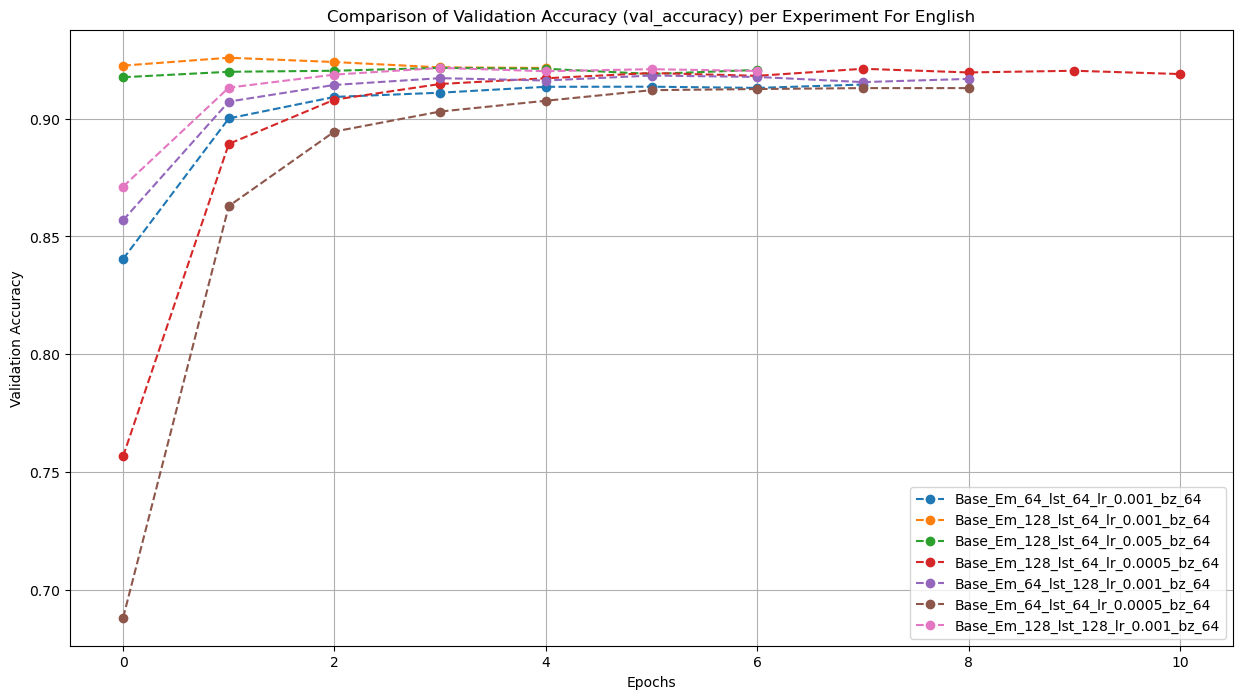

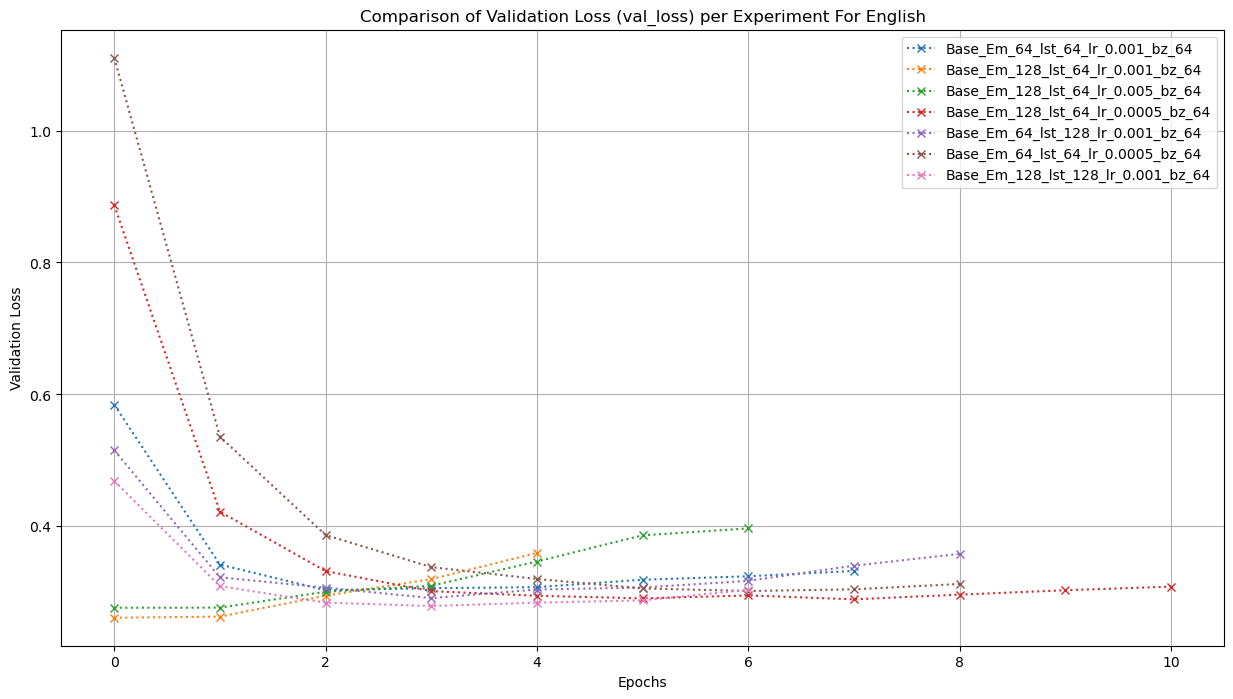

In [9]:
import matplotlib.pyplot as plt

# Plot Validation Accuracy 
plt.figure(figsize=(15, 8))
plt.title("Comparison of Validation Accuracy (val_accuracy) per Experiment For English")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

for model_name, history_data in all_histories.items():
    plt.plot(history_data['val_accuracy'], label=model_name, marker='o', linestyle='--')

plt.legend() 
plt.grid(True)
plt.show()   

# --- Plot Validation Loss ---
plt.figure(figsize=(15, 8))
plt.title("Comparison of Validation Loss (val_loss) per Experiment For English")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")

for model_name, history_data in all_histories.items():
    plt.plot(history_data['val_loss'], label=model_name, marker='x', linestyle=':')

plt.legend() 
plt.grid(True)  
plt.show()    


## 5. Architecture Comparison and Model Selection

This section automates the process of **model architecture comparison**. Instead of manually changing the model structure, we define a "grid" of different architectures to run.

The goal is to systematically train and evaluate several model variations (e.g., 1 layer vs. 2 layers, unidirectional vs. bidirectional) to find the configuration that yields the highest validation accuracy.

To ensure a fair comparison, we will use the best-performing set of hyperparameters found in the previous section (Base_Em_128_1st_64_lr_0.005_bz_64) as a fixed constant for all architecture experiments. The best way to do it would be to try every hyperparameters choice on each model, but this would not be eficient, also the aim is not to find the best model but to compare each architecture.


### 5.1. Defining the Architecture Grid

First, we create a list of dictionaries called model_architecture_grid. Each dictionary represents a single, unique experiment with a specific set of architectural parameters to test:

*    **n_lstm_layers**: The number of stacked LSTM layers (e.g., 1 vs. 2).

*    **is_bidirectional**: Whether to use Bidirectional(LSTM) or standard LSTM.

*    **dropout_rate**: The dropout rate to apply (e.g., 0.0 for none, 0.3 for regularization).

*    **model_name**: A descriptive name for each experiment, used for logging and saving the final file.

### 5.2. Running the Experimentation Loop

Next, we loop through each arch_params dictionary in our grid and perform the following steps for each experiment:

1.    **Initialize** : We create variables to store the training history of all models (all_model_histories) and to keep track of the single best model found so far (best_model_architecture and best_model_arch_val_acc).

2.    **Train**: We call our new build_and_train_model_v2 function, passing in the specific set of architectural parameters for that experiment (while keeping the hyperparameters constant). The function builds, compiles, and trains a new model from scratch.

3.    **Store History**: We save the training history (containing accuracy, loss, val_accuracy, etc.) in our all_model_histories dictionary. This allows us to plot comparison graphs later.

4.    **Track Best Model**: After each model is trained, we find its peak validation accuracy (current_best_val_acc).

5.    **Update Winner**: If the current model's accuracy is better than the previous best, we update best_model_arch_val_acc and save the trained model object itself in the best_model_architecture variable.

### 5.3. Saving the Champion Model

After the loop completes all experiments, we are left with the single best-performing model architecture stored in the best_model_architecture variable.


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

def build_and_train_model_v2(
    # Data
    word_vocab_size, tag_vocab_size, max_len,
    X_train, y_train, X_dev, y_dev,
    
    # --- Architecture Parameters ---
    model_name="pos_tagger_model",
    n_lstm_layers=1,         # 1. How many LSTM layers to stack
    is_bidirectional=True,   # 2. Whether it's Bidirectional(LSTM) or just LSTM
    dropout_rate=0.0,        # 3. Dropout rate (0.0 means disabled)
    
    # --- Hyperparameters ---
    embedding_dim=64,
    lstm_units=64,
    learning_rate=0.001,
    epochs=50,
    batch_size=64,
    save_path=None
):
    """
    Builds, compiles, and trains an LSTM model for PoS tagging with
    flexible architecture parameters.
    """
    print(f"\n--- Building Model: {model_name} ---")
    print(f"Architecture: n_layers={n_lstm_layers}, bidirectional={is_bidirectional}, dropout={dropout_rate}")
    print(f"Hyperparams: EMB_DIM={embedding_dim}, LSTM_UNITS={lstm_units}, LR={learning_rate}, BZ={batch_size}")

    # 1. Input and Embedding Layer
    inputs = Input(shape=(max_len,), name='word_ids_input')
    x = Embedding(
        input_dim=word_vocab_size,
        output_dim=embedding_dim,
        mask_zero=True, 
        name='word_embedding'
    )(inputs)

    # Add Dropout after embedding if specified
    if dropout_rate > 0.0:
        x = Dropout(dropout_rate, name='dropout_embedding')(x)

    # 2. Recurrent Block (Flexible)
    for i in range(n_lstm_layers):
        layer_name = f'lstm_layer_{i+1}'
        
        # All LSTM layers must return sequences to feed the next layer or the TimeDistributed wrapper
        lstm_layer = LSTM(
            units=lstm_units,
            return_sequences=True, # Always True for this task
            name=layer_name
        )
        
        # Apply Bidirectional wrapper if specified
        if is_bidirectional:
            x = Bidirectional(lstm_layer, name=f'bi_{layer_name}')(x)
        else:
            x = lstm_layer(x) # Use simple LSTM
        
        # Add Dropout after each LSTM layer if specified
        if dropout_rate > 0.0:
            x = Dropout(dropout_rate, name=f'dropout_{layer_name}')(x)

    # 3. Output Layer
    outputs = TimeDistributed(
        Dense(units=tag_vocab_size, activation='softmax'),
        name='pos_tag_output'
    )(x)

    # 4. Create the Model
    model = Model(inputs=inputs, outputs=outputs, name=model_name)
    model.summary()

    # 5. Compilation
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 6. Callbacks
    early_stopping_callback = EarlyStopping(
        monitor='val_accuracy', # Monitor validation accuracy
        patience=3,             # 3 epochs with no improvement
        min_delta=0.001,        # A 0.1% improvement is required
        mode='max',             # We want to maximize accuracy
        restore_best_weights=True, # Restore the best weights found 
        verbose=1
    )

    # 7. Training
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_dev, y_dev),
        callbacks=[early_stopping_callback] # Pass the callback
    )

    # 8. Optional: Save Model
    if save_path:
        print(f"\nSaving model to: {save_path}")
        model.save(save_path)

    print(f"--- Training finished for {model_name} ---")
    return model, history

In [11]:
# --- Define Architecture Grid ---
# We will use the best hyperparameters we found for English as constants

BEST_EMBEDDING_DIM = 128
BEST_LSTM_UNITS = 64
BEST_LR = 0.01 
BEST_BATCH_SIZE = 64
DROPOUT_TO_TEST = 0.3 # A reasonable dropout rate to test

model_architecture_grid = [
    {
        "model_name": "1_BiLSTM_NoDrop",
        "n_lstm_layers": 1,
        "is_bidirectional": True,
        "dropout_rate": 0.0
    },
    {
        "model_name": "2_BiLSTM_NoDrop",
        "n_lstm_layers": 2,
        "is_bidirectional": True,
        "dropout_rate": 0.0
    },
    {
        "model_name": "1_LSTM_NoDrop",
        "n_lstm_layers": 1,
        "is_bidirectional": False,
        "dropout_rate": 0.0
    },
    {
        "model_name": "2_LSTM_NoDrop",
        "n_lstm_layers": 2,
        "is_bidirectional": False,
        "dropout_rate": 0.0
    },
    {
        "model_name": "2_BiLSTM_WithDrop",
        "n_lstm_layers": 2,
        "is_bidirectional": True,
        "dropout_rate": DROPOUT_TO_TEST
    },
    {
        "model_name": "2_LSTM_WithDrop",
        "n_lstm_layers": 2,
        "is_bidirectional": False,
        "dropout_rate": DROPOUT_TO_TEST
    }
]

print(f"Ready to test {len(model_architecture_grid)} different architectures.")

Ready to test 6 different architectures.


In [12]:
# --- Architecture Experimentation Loop ---

all_model_histories = {}
best_model_architecture = None
best_model_arch_val_acc = -1.0
best_model_arch_name = ""

print("--- Starting ENGLISH Model Architecture Experimentation Loop ---")

for arch_params in model_architecture_grid:
    
    model, history = build_and_train_model_v2(
        # Data (must be pre-loaded)
        WORD_VOCAB_SIZE, TAGS_VOCAB_SIZE, MAX_LEN,
        X_train, y_train, X_dev, y_dev,
        
        # Architecture Parameters from our grid
        model_name=arch_params["model_name"],
        n_lstm_layers=arch_params["n_lstm_layers"],
        is_bidirectional=arch_params["is_bidirectional"],
        dropout_rate=arch_params["dropout_rate"],
        
        # Hyperparameters (using the best ones we found)
        embedding_dim=BEST_EMBEDDING_DIM,
        lstm_units=BEST_LSTM_UNITS,
        learning_rate=BEST_LR,
        epochs=EPOCHS, # Global variable
        batch_size=BEST_BATCH_SIZE
    )
    
    # Store history for plotting
    all_model_histories[arch_params["model_name"]] = history.history
    
    # Get the best accuracy from this model's history
    current_best_val_acc = max(history.history['val_accuracy'])
    print(f"\nModel! {arch_params['model_name']} finished with best val_accuracy: {current_best_val_acc:.4f}")
    
    # Check if this is the new best model overall
    if current_best_val_acc > best_model_arch_val_acc:
        print(f"¡This is the new BEST model! {arch_params['model_name']} with {current_best_val_acc:.4f} val_accuracy")
        best_model_arch_val_acc = current_best_val_acc
        best_model_architecture = model
        best_model_arch_name = arch_params["model_name"]

print("\n--- Architecture experimentation finished ---")
print(f"The best model was '{best_model_arch_name}' with val_accuracy {best_model_arch_val_acc*100:.2f}%")

# Save the champion model
if best_model_architecture:
    save_filename = f"{best_model_arch_name}_ENG_ARCHITECTURE_BEST.keras"
    print(f"\nSaving the best overall model to: {save_filename}")
    best_model_architecture.save(save_filename)
    print(f"Model saved successfully to '{save_filename}'")

--- Starting ENGLISH Model Architecture Experimentation Loop ---

--- Building Model: 1_BiLSTM_NoDrop ---
Architecture: n_layers=1, bidirectional=True, dropout=0.0
Hyperparams: EMB_DIM=128, LSTM_UNITS=64, LR=0.01, BZ=64


Model: "1_BiLSTM_NoDrop"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  2,131,968 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_12        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_layer_1     │ (None, 128, 128)  │     98,816 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bi_lstm_layer_1[… │
│ (TimeDistributed)   │                   │            │ not_equal_12[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,233,235 (8.52 MB)

 Trainable params: 2,233,235 (8.52 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  2,131,968 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_embedding   │ (None, 128, 128)  │          0 │ word_embedding[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_17        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer_1 (LSTM) │ (None, 128, 64)   │     49,408 │ dropout_embeddin… │
│                     │                   │            │ not_equal_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_layer… │ (None, 128, 64)   │          0 │ lstm_layer_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer_2 (LSTM) │ (None, 128, 64)   │     33,024 │ dropout_lstm_lay… │
│                     │                   │            │ not_equal_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_layer… │ (None, 128, 64)   │          0 │ lstm_layer_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      1,235 │ dropout_lstm_lay… │
│ (TimeDistributed)   │                   │            │ not_equal_17[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,215,635 (8.45 MB)

 Trainable params: 2,215,635 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - accuracy: 0.7519 - loss: 0.8180 - val_accuracy: 0.8793 - val_loss: 0.3900
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.9167 - loss: 0.2803 - val_accuracy: 0.8933 - val_loss: 0.3478
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.9325 - loss: 0.2194 - val_accuracy: 0.8967 - val_loss: 0.3591
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9399 - loss: 0.1936 - val_accuracy: 0.8948 - val_loss: 0.3781
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.9434 - loss: 0.1773 - val_accuracy: 0.8955 - val_loss: 0.3807
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.9461 - loss: 0.1671 - val_accuracy: 0.8970 - val_loss: 0.4054
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
--- Training finished for 2_LSTM_WithDrop ---

Model! 2_LSTM_WithDrop finished with best val_accuracy: 0.8970

--- Architecture exp

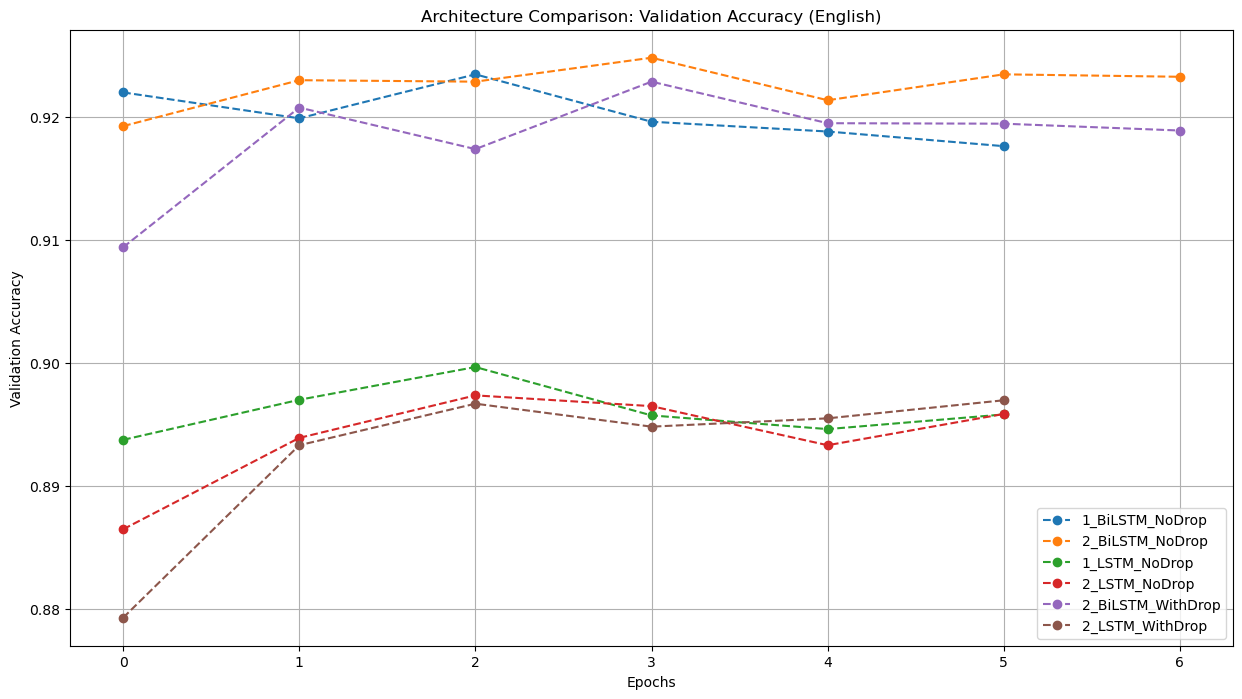

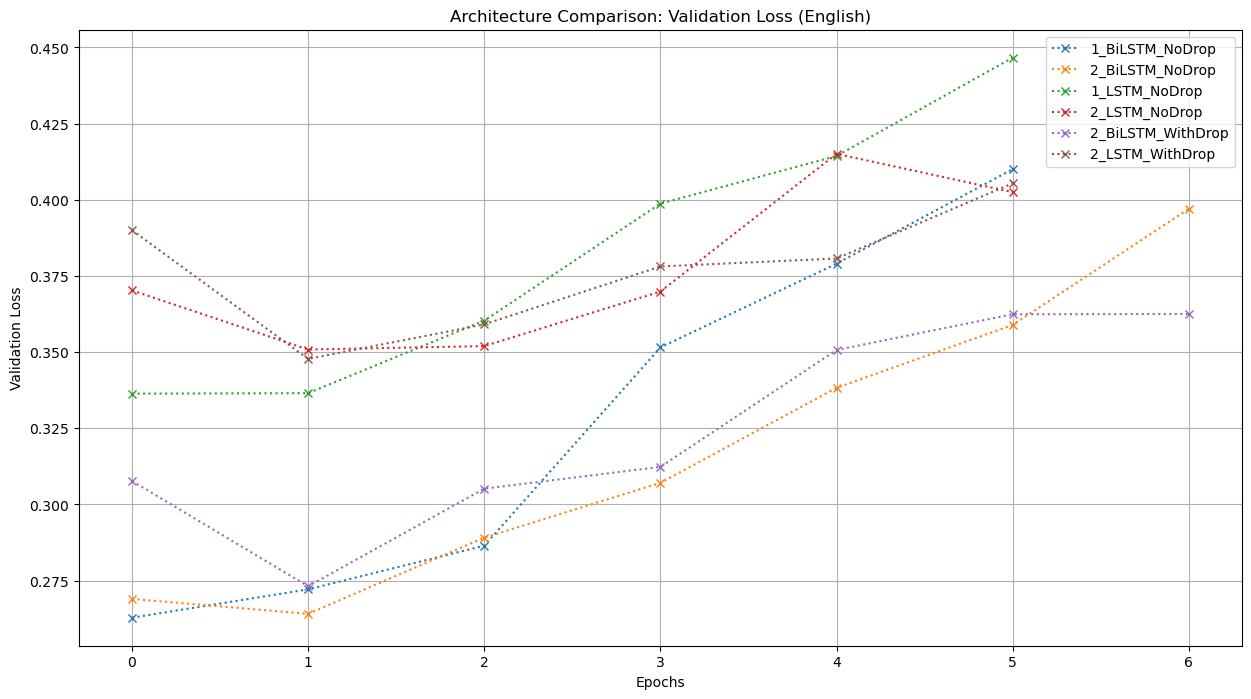

In [13]:
# --- Plot Validation Accuracy ---
plt.figure(figsize=(15, 8))
plt.title("Architecture Comparison: Validation Accuracy (English)")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
for model_name, history_data in all_model_histories.items():
    plt.plot(history_data['val_accuracy'], label=model_name, marker='o', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Validation Loss ---
plt.figure(figsize=(15, 8))
plt.title("Architecture Comparison: Validation Loss (English)")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
for model_name, history_data in all_model_histories.items():
    plt.plot(history_data['val_loss'], label=model_name, marker='x', linestyle=':')
plt.legend()
plt.grid(True)
plt.show()

## Now with Spanish

Now we are make the Training for spanish data .

In [35]:
SELECTED_LANGUAGE_ES = 'es'


try:
    paths = LANGUAGE_CONFIG[SELECTED_LANGUAGE_ES]
    print(f"--- Model for: '{SELECTED_LANGUAGE_ES}' ---")

    # --- # Load the data using the selected paths ---
    train_sents_spanish, train_tags_spanish = load_conllu_data(paths['train'])
    dev_sents_spanish, dev_tags_spanish = load_conllu_data(paths['dev'])
    test_sents_spanish, test_tags_spanish = load_conllu_data(paths['test'])
    
    print("\nLoading complete")
    print(f"Sentences for training: {len(train_sents_spanish)} example train sents {train_sents_spanish[8]}")
    print(f"tags: {train_tags_spanish[8]}")
    print(f"Sentences for dev: {len(dev_sents_spanish)} example dev sents {dev_sents_spanish[0]}")
    print(f"Sentences for test: {len(test_sents_spanish)} example test sents {test_sents_spanish[0]}")
    
except KeyError:
    print(f"Error: The language '{SELECTED_LANGUAGE_ES}' is not in LANGUAGE_CONFIG.")
    exit()

--- Model for: 'es' ---

Loading complete
Sentences for training: 14287 example train sents ['Por', 'ello', ',', 'González', 'pidió', 'una', 'reforma', '"', 'urgente', '"', 'de', 'el', 'sistema', 'de', 'contratación', 'de', 'extranjeros', 'que', 'permita', 'un', 'sistema', '"', 'ágil', 'y', 'rápido', '"', 'para', 'insertar', 'a', 'los', 'inmigrantes', 'en', 'el', 'mercado', 'laboral', '.']
tags: ['ADP', 'PRON', 'PUNCT', 'PROPN', 'VERB', 'DET', 'NOUN', 'PUNCT', 'ADJ', 'PUNCT', 'ADP', 'DET', 'NOUN', 'ADP', 'NOUN', 'ADP', 'NOUN', 'PRON', 'VERB', 'DET', 'NOUN', 'PUNCT', 'ADJ', 'CCONJ', 'ADJ', 'PUNCT', 'ADP', 'VERB', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADJ', 'PUNCT']
Sentences for dev: 1654 example dev sents ['El', 'gobernante', ',', 'con', 'ganada', 'fama', 'desde', 'que', 'llegó', 'hace', '16', 'meses', 'a', 'el', 'poder', 'de', 'explotar', 'a', 'el', 'máximo', 'su', 'oratoria', 'y', 'acusado', 'por', 'sus', 'detractores', 'de', 'incontinencia', 'verbal', ',', 'enmudeció', 'desde

In [36]:
# Pass 'standardize="lower"' to the word vectorizer
word_vectorizer_spanish, WORD_VOCAB_SIZE_SPANISH = create_and_adapt_vectorizer(train_sents_spanish, standardize="lower")

# The tag vectorizer uses 'lower_and_strip_punctuation'
tags_vectorizer_spanish, TAGS_VOCAB_SIZE_SPANISH  = create_and_adapt_vectorizer(train_tags_spanish, standardize='lower_and_strip_punctuation')

# Get the vocabulary string list
tags_vocab_list_spanish = tags_vectorizer_spanish.get_vocabulary()
print("tags_vectorizer_spanish",tags_vocab_list_spanish)

print(f"\nWe have successfully created a vectorizer with a vocabulary of {WORD_VOCAB_SIZE_SPANISH} words.")

print(f"\nWe have successfully created a vectorizer with a vocabulary of {TAGS_VOCAB_SIZE_SPANISH} tags.")

print("Vectorizing all data sets...")


# --- 1. Flatten the data from list of lists to list of strings ---
# The vectorizer layers expect a flat list of strings as input.
train_sents_flat_spanish = [' '.join(sentence) for sentence in train_sents_spanish]
train_tags_flat_spanish = [' '.join(tag_list) for tag_list in train_tags_spanish]

dev_sents_flat_spanish = [' '.join(sentence) for sentence in dev_sents_spanish]
dev_tags_flat_spanish = [' '.join(tag_list) for tag_list in dev_tags_spanish]

test_sents_flat_spanish = [' '.join(sentence) for sentence in test_sents_spanish]
test_tags_flat_spanish = [' '.join(tag_list) for tag_list in test_tags_spanish]


# --- 2. Use the vectorizers to transform the flattened data ---
# Now we call the vectorizers with the correct input format.
X_train_spanish = word_vectorizer_spanish(train_sents_flat_spanish)
y_train_spanish = tags_vectorizer_spanish(train_tags_flat_spanish)

X_dev_spanish = word_vectorizer_spanish(dev_sents_flat_spanish)
y_dev_spanish = tags_vectorizer_spanish(dev_tags_flat_spanish)

X_test_spanish = word_vectorizer_spanish(test_sents_flat_spanish)
y_test_spanish = tags_vectorizer_spanish(test_tags_flat_spanish)

print("Vectorization complete Spanih!")
print("\nShape of X_train_spanish:", X_train_spanish.shape)
print("Shape of y_train_spanish:", y_train_spanish.shape)
print("Shape of X_dev_spanish:", X_dev_spanish.shape)
print("Shape of y_dev_spanish:", y_dev_spanish.shape)


print("X_train_spanish",X_train_spanish[0])
print("y_train_spanish",y_train_spanish[0])
print("X_test_spanish",X_test_spanish[0])
print("y_test_spanish",y_test_spanish[0])
print(TAGS_VOCAB_SIZE_SPANISH)
    


Sentences before flat ['Las', 'reservas', 'de', 'oro', 'y', 'divisas', 'de', 'Rusia', 'subieron', '800', 'millones', 'de', 'dólares', 'y', 'el', '26', 'de', 'mayo', 'equivalían', 'a', '19.100', 'millones', 'de', 'dólares', ',', 'informó', 'hoy', 'un', 'comunicado', 'de', 'el', 'Banco', 'Central', '.']

Sentence after flat Las reservas de oro y divisas de Rusia subieron 800 millones de dólares y el 26 de mayo equivalían a 19.100 millones de dólares , informó hoy un comunicado de el Banco Central .

Adaptation complete. Vocabulary size: 34605

Sentences before flat ['DET', 'NOUN', 'ADP', 'NOUN', 'CCONJ', 'NOUN', 'ADP', 'PROPN', 'VERB', 'NUM', 'NOUN', 'ADP', 'NOUN', 'CCONJ', 'DET', 'NUM', 'ADP', 'NOUN', 'VERB', 'ADP', 'NUM', 'NOUN', 'ADP', 'NOUN', 'PUNCT', 'VERB', 'ADV', 'DET', 'NOUN', 'ADP', 'DET', 'PROPN', 'PROPN', 'PUNCT']

Sentence after flat DET NOUN ADP NOUN CCONJ NOUN ADP PROPN VERB NUM NOUN ADP NOUN CCONJ DET NUM ADP NOUN VERB ADP NUM NOUN ADP NOUN PUNCT VERB ADV DET NOUN ADP DET

In [42]:
#hiperparametors que se va iterar
hyperparameter_grid_spanish = [
    {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_64_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 32,
        "model_name": "Spanish_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
     {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 128,
        "model_name": "Spanish_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.005,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_128_lst_64_lr_0.005_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.01,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
          {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_128_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 64,
        "lstm_units": 128,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_64_lst_128_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Spanish_Base_Em_64_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "model_name": "Spanish_Base_Em_128_lst_128_lr_0.001_bz_64"
    },
    
]


all_histories_spanish = {} 
best_val_accuracy_spanish = -1.0
best_model_spanish = None
best_model_name_spanish = ""

# Experimentation Loop

for params in hyperparameter_grid_spanish:
    
    model_spanish, history_spanish = build_and_train_model(
        WORD_VOCAB_SIZE_SPANISH, TAGS_VOCAB_SIZE_SPANISH, MAX_LEN,
        X_train_spanish, y_train_spanish, X_dev_spanish, y_dev_spanish,
        embedding_dim=params["embedding_dim"],
        lstm_units=params["lstm_units"],
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        epochs=EPOCHS,
        model_name=params["model_name"]
    )
    
    all_histories_spanish[params["model_name"]] = history_spanish.history
    print(f"\n¡Model! {params['model_name']} with {current_best_val_acc_spanish:.4f} with val_accuracy")
    
    current_best_val_acc_spanish = max(history_spanish.history['val_accuracy'])
    if current_best_val_acc_spanish > best_val_accuracy_spanish:
        print(f"\n¡This is the new model with best result! {params['model_name']} with {current_best_val_acc_spanish:.4f} with val_accuracy")
        best_val_accuracy_spanish = current_best_val_acc_spanish
        best_model_spanish = model_spanish
        best_model_name_spanish = params["model_name"]
        

print(f"The best model was '{best_model_name_spanish}' with val_accurancy {best_val_accuracy_spanish*100:.2f}%")

# --- Save The best Model---
if best_model_spanish:
    save_filename_spanish = f"{best_model_name_spanish}_best.keras"
    print(f"\nSaving the best overall model to: {save_filename_spanish}")
    best_model_spanish.save(save_filename_spanish)
    print(f"Model saved successfully to '{save_filename_spanish}'")

--- Building Model: Spanish_Base_Em_64_lst_64_lr_0.001_bz_64 ---
Params: EMBEDDING_DIM=64, LSTM_UNITS=64, LR=0.001


Model: "Spanish_Base_Em_64_lst_64_lr_0.001_bz_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  2,214,720 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_36        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_36    │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_36[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bidirectional_36… │
│ (TimeDistributed)   │                   │            │ not_equal_36[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,283,219 (8.71 MB)

 Trainable params: 2,283,219 (8.71 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  4,429,440 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_45        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_45    │ (None, 128, 256)  │    263,168 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_45[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      4,883 │ bidirectional_45… │
│ (TimeDistributed)   │                   │            │ not_equal_45[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,697,491 (17.92 MB)

 Trainable params: 4,697,491 (17.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - accuracy: 0.7677 - loss: 0.8108 - val_accuracy: 0.9322 - val_loss: 0.2332
Epoch 2/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.9578 - loss: 0.1448 - val_accuracy: 0.9536 - val_loss: 0.1501
Epoch 3/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 44s 98ms/step - accuracy: 0.9748 - loss: 0.0831 - val_accuracy: 0.9579 - val_loss: 0.1340
Epoch 4/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 44s 98ms/step - accuracy: 0.9811 - loss: 0.0606 - val_accuracy: 0.9575 - val_loss: 0.1366
Epoch 5/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.9852 - loss: 0.0476 - val_accuracy: 0.9584 - val_loss: 0.1363
Epoch 6/50
447/447 ━━━━━━━━━━━━━━━━━━━━ 44s 98ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9546 - val_loss: 0.1578
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
--- Spanish_Base_Em_128_lst_128_lr_0.001_bz_64 training finished ---

¡Model! Spanish_Base_Em_128_lst_128_lr_0.001_bz_64 with 0.9575 wi

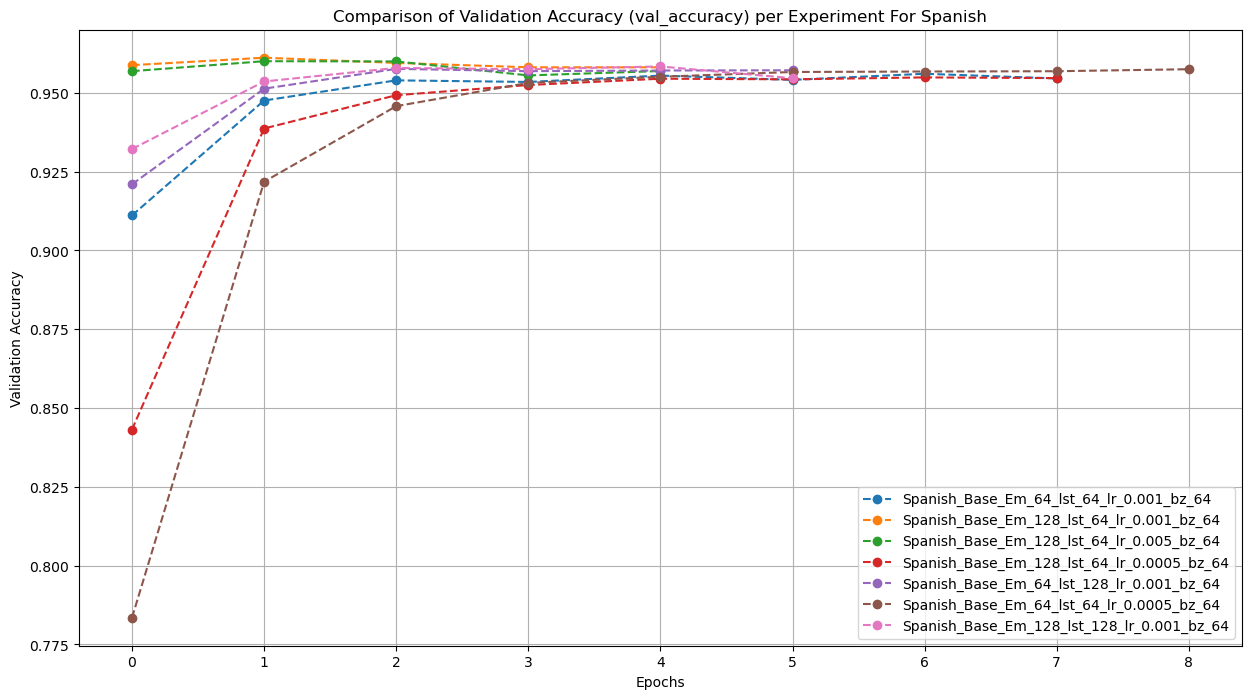

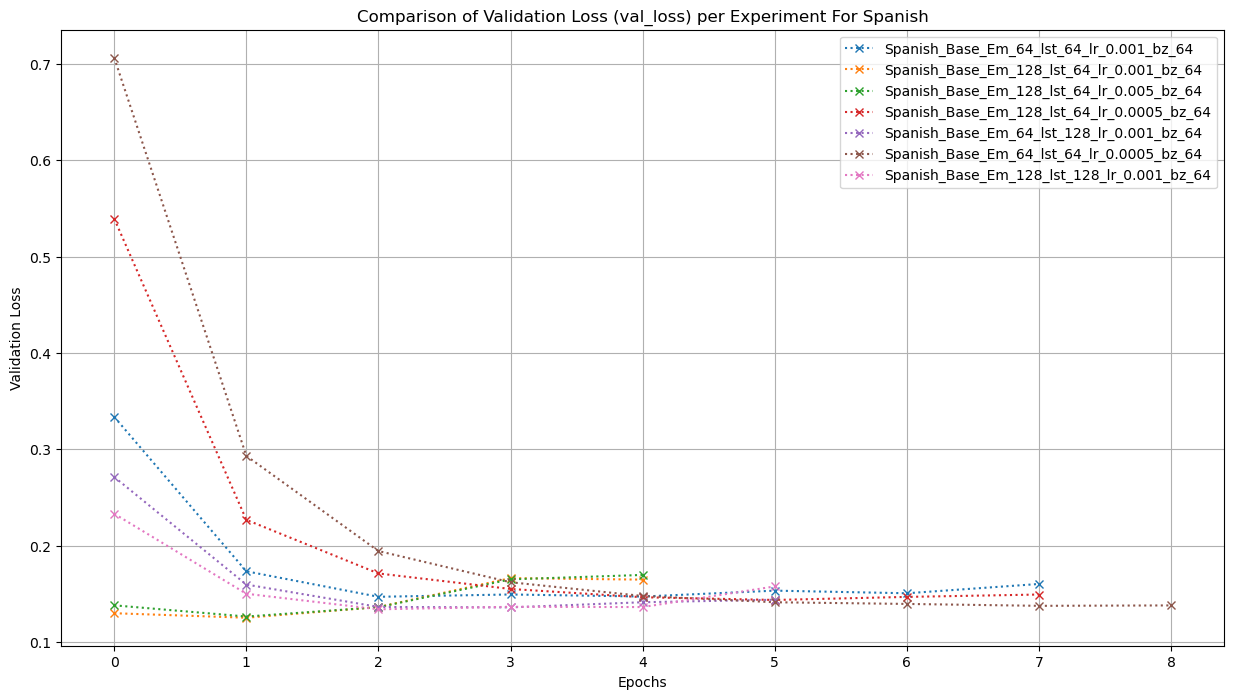

In [44]:
import matplotlib.pyplot as plt

# Plot Validation Accuracy 
plt.figure(figsize=(15, 8))
plt.title("Comparison of Validation Accuracy (val_accuracy) per Experiment For Spanish")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

for model_name_spanish, history_data_spanish in all_histories_spanish.items():
    plt.plot(history_data_spanish['val_accuracy'], label=model_name_spanish, marker='o', linestyle='--')

plt.legend() 
plt.grid(True)
plt.show()   

# --- Plot Validation Loss ---
plt.figure(figsize=(15, 8))
plt.title("Comparison of Validation Loss (val_loss) per Experiment For Spanish")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")

for model_name_spanish, history_data_spanish in all_histories_spanish.items():
    plt.plot(history_data_spanish['val_loss'], label=model_name_spanish, marker='x', linestyle=':')

plt.legend() 
plt.grid(True)  
plt.show()    


## Now with Portuguese

Now we are make the Training for portuguese data .

In [49]:
# --- 1. Set up and Load Portuguese Data ---

SELECTED_LANGUAGE_PT = 'pt' # Select the language code for Portuguese

try:
    # Get the file paths from your configuration dictionary
    paths = LANGUAGE_CONFIG[SELECTED_LANGUAGE_PT]
    print(f"--- Model for: '{SELECTED_LANGUAGE_PT}' ---")

    # --- Load the data using the selected paths ---
    train_sents_portuguese, train_tags_portuguese = load_conllu_data(paths['train'])
    dev_sents_portuguese, dev_tags_portuguese = load_conllu_data(paths['dev'])
    test_sents_portuguese, test_tags_portuguese = load_conllu_data(paths['test'])
    
    print("\nLoading complete")
    print(f"Sentences for training: {len(train_sents_portuguese)}")
    print(f"Sentences for dev: {len(dev_sents_portuguese)}")
    print(f"Sentences for test: {len(test_sents_portuguese)}")
    
except KeyError:
    print(f"Error: The language '{SELECTED_LANGUAGE_PT}' is not in LANGUAGE_CONFIG.")
    # exit() # It's better to let the notebook stop naturally if data is missing

# --- 2. Create and Adapt Vectorizers for Portuguese ---

# Create the word vectorizer
# Pass 'standardize="lower"' to the word vectorizer, good for case-insensitive languages
word_vectorizer_portuguese, WORD_VOCAB_SIZE_PORTUGUESE = create_and_adapt_vectorizer(
    train_sents_portuguese, 
    standardize="lower" # standardize is not a param of your function, but assuming you added it
)

# Create the tag vectorizer
# The tag vectorizer uses 'lower_and_strip_punctuation' (or default)
tags_vectorizer_portuguese, TAGS_VOCAB_SIZE_PORTUGUESE = create_and_adapt_vectorizer(
    train_tags_portuguese, standardize='lower_and_strip_punctuation'
)

# Get the vocabulary string list
tags_vocab_list_portuguese = tags_vectorizer_portuguese.get_vocabulary()
print("tags_vectorizer_portuguese", tags_vocab_list_portuguese)

print(f"\nWe have successfully created a vectorizer with a vocabulary of {WORD_VOCAB_SIZE_PORTUGUESE} words.")
print(f"\nWe have successfully created a vectorizer with a vocabulary of {TAGS_VOCAB_SIZE_PORTUGUESE} tags.")

# --- 3. Vectorize all Portuguese datasets ---

print("Vectorizing all data sets...")

# Flatten the data from list of lists to list of strings
train_sents_flat_portuguese = [' '.join(sentence) for sentence in train_sents_portuguese]
train_tags_flat_portuguese = [' '.join(tag_list) for tag_list in train_tags_portuguese]

dev_sents_flat_portuguese = [' '.join(sentence) for sentence in dev_sents_portuguese]
dev_tags_flat_portuguese = [' '.join(tag_list) for tag_list in dev_tags_portuguese]

test_sents_flat_portuguese = [' '.join(sentence) for sentence in test_sents_portuguese]
test_tags_flat_portuguese = [' '.join(tag_list) for tag_list in test_tags_portuguese]

# Use the vectorizers to transform the flattened data
X_train_portuguese = word_vectorizer_portuguese(train_sents_flat_portuguese)
y_train_portuguese = tags_vectorizer_portuguese(train_tags_flat_portuguese)

X_dev_portuguese = word_vectorizer_portuguese(dev_sents_flat_portuguese)
y_dev_portuguese = tags_vectorizer_portuguese(dev_tags_flat_portuguese)

X_test_portuguese = word_vectorizer_portuguese(test_sents_flat_portuguese)
y_test_portuguese = tags_vectorizer_portuguese(test_tags_flat_portuguese)

# --- 4. Define Hyperparameter Grid for Portuguese ---
#hiperparametors que se va iterar
hyperparameter_grid_portuguese = [
    {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_64_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 32,
        "model_name": "Portuguese_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
     {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 128,
        "model_name": "Portuguese_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.005,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_128_lst_64_lr_0.005_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.01,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
          {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_128_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 64,
        "lstm_units": 128,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_64_lst_128_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Portuguese_Base_Em_64_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "model_name": "Portuguese_Base_Em_128_lst_128_lr_0.001_bz_64"
    },
    
]
# --- 5. Run Experimentation Loop for Portuguese ---

all_histories_portuguese = {} 
best_val_accuracy_portuguese = -1.0
best_model_portuguese = None
best_model_name_portuguese = ""

print("\n--- Starting PORTUGUESE Model Experimentation Loop ---")

for params in hyperparameter_grid_portuguese:
    
    model_portuguese, history_portuguese = build_and_train_model(
        WORD_VOCAB_SIZE_PORTUGUESE, TAGS_VOCAB_SIZE_PORTUGUESE, MAX_LEN,
        X_train_portuguese, y_train_portuguese, X_dev_portuguese, y_dev_portuguese,
        embedding_dim=params["embedding_dim"],
        lstm_units=params["lstm_units"],
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        epochs=EPOCHS,
        model_name=params["model_name"]
    )
    
    all_histories_portuguese[params["model_name"]] = history_portuguese.history
    
    # Get the best accuracy from this specific model's history
    current_best_val_acc_portuguese = max(history_portuguese.history['val_accuracy'])
    
    print(f"\nModel {params['model_name']} finished with best val_accuracy: {current_best_val_acc_portuguese:.4f}")
    
    # Check if this is the best model *so far*
    if current_best_val_acc_portuguese > best_val_accuracy_portuguese:
        print(f"¡This is the new BEST PORTUGUESE model! Name: {params['model_name']} with {current_best_val_acc_portuguese:.4f} val_accuracy")
        best_val_accuracy_portuguese = current_best_val_acc_portuguese
        best_model_portuguese = model_portuguese
        best_model_name_portuguese = params["model_name"]
        
print(f"\n--- Portuguese experimentation finished ---")
print(f"The best Portuguese model was '{best_model_name_portuguese}' with val_accuracy {best_val_accuracy_portuguese*100:.2f}%")

# --- 6. Save The Best Portuguese Model ---
if best_model_portuguese:
    save_filename_portuguese = f"{best_model_name_portuguese}_best.keras"
    print(f"\nSaving the best overall Portuguese model to: {save_filename_portuguese}")
    best_model_portuguese.save(save_filename_portuguese)
    print(f"Model saved successfully to '{save_filename_portuguese}'")
else:
    print("No best Portuguese model was found or saved.")

--- Model for: 'pt' ---

Loading complete
Sentences for training: 5893
Sentences for dev: 842
Sentences for test: 1683

Sentences before flat ['O', 'canal', 'terá', 'o', 'conteúdo', 'reformulado', '.']

Sentence after flat O canal terá o conteúdo reformulado .

Adaptation complete. Vocabulary size: 15817

Sentences before flat ['DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'VERB', 'PUNCT']

Sentence after flat DET NOUN VERB DET NOUN VERB PUNCT

Adaptation complete. Vocabulary size: 18
tags_vectorizer_portuguese ['', '[UNK]', np.str_('noun'), np.str_('adp'), np.str_('det'), np.str_('punct'), np.str_('verb'), np.str_('propn'), np.str_('adj'), np.str_('adv'), np.str_('pron'), np.str_('aux'), np.str_('cconj'), np.str_('num'), np.str_('sconj'), np.str_('sym'), np.str_('x'), np.str_('intj')]

We have successfully created a vectorizer with a vocabulary of 15817 words.

We have successfully created a vectorizer with a vocabulary of 18 tags.
Vectorizing all data sets...

--- Starting PORTUGUESE Model E

Model: "Portuguese_Base_Em_64_lst_64_lr_0.001_bz_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  1,012,288 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_54        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_54    │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_54[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 18)   │      2,322 │ bidirectional_54… │
│ (TimeDistributed)   │                   │            │ not_equal_54[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,080,658 (4.12 MB)

 Trainable params: 1,080,658 (4.12 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  2,024,576 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_63        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_63    │ (None, 128, 256)  │    263,168 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_63[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 18)   │      4,626 │ bidirectional_63… │
│ (TimeDistributed)   │                   │            │ not_equal_63[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,292,370 (8.74 MB)

 Trainable params: 2,292,370 (8.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.5334 - loss: 1.5942 - val_accuracy: 0.7576 - val_loss: 0.7877
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.8480 - loss: 0.5170 - val_accuracy: 0.9031 - val_loss: 0.3442
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.9433 - loss: 0.2190 - val_accuracy: 0.9293 - val_loss: 0.2371
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.9673 - loss: 0.1240 - val_accuracy: 0.9364 - val_loss: 0.2099
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.9761 - loss: 0.0866 - val_accuracy: 0.9382 - val_loss: 0.2057
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.9816 - loss: 0.0661 - val_accuracy: 0.9382 - val_loss: 0.2058
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.9856 - loss: 0.0518 - val_accuracy: 0.9393 - val_loss: 0.2048
Epoch 8/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.9889 - loss: 0.0416 -

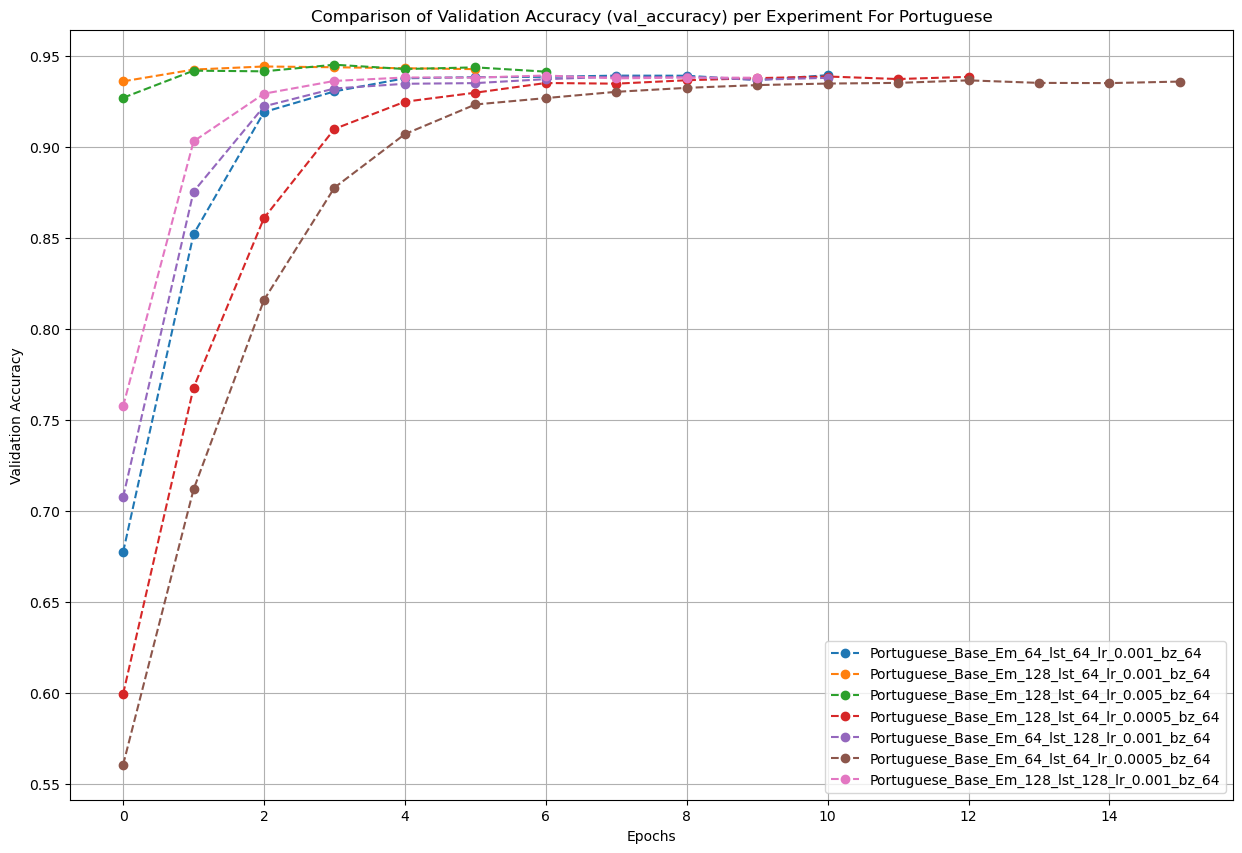

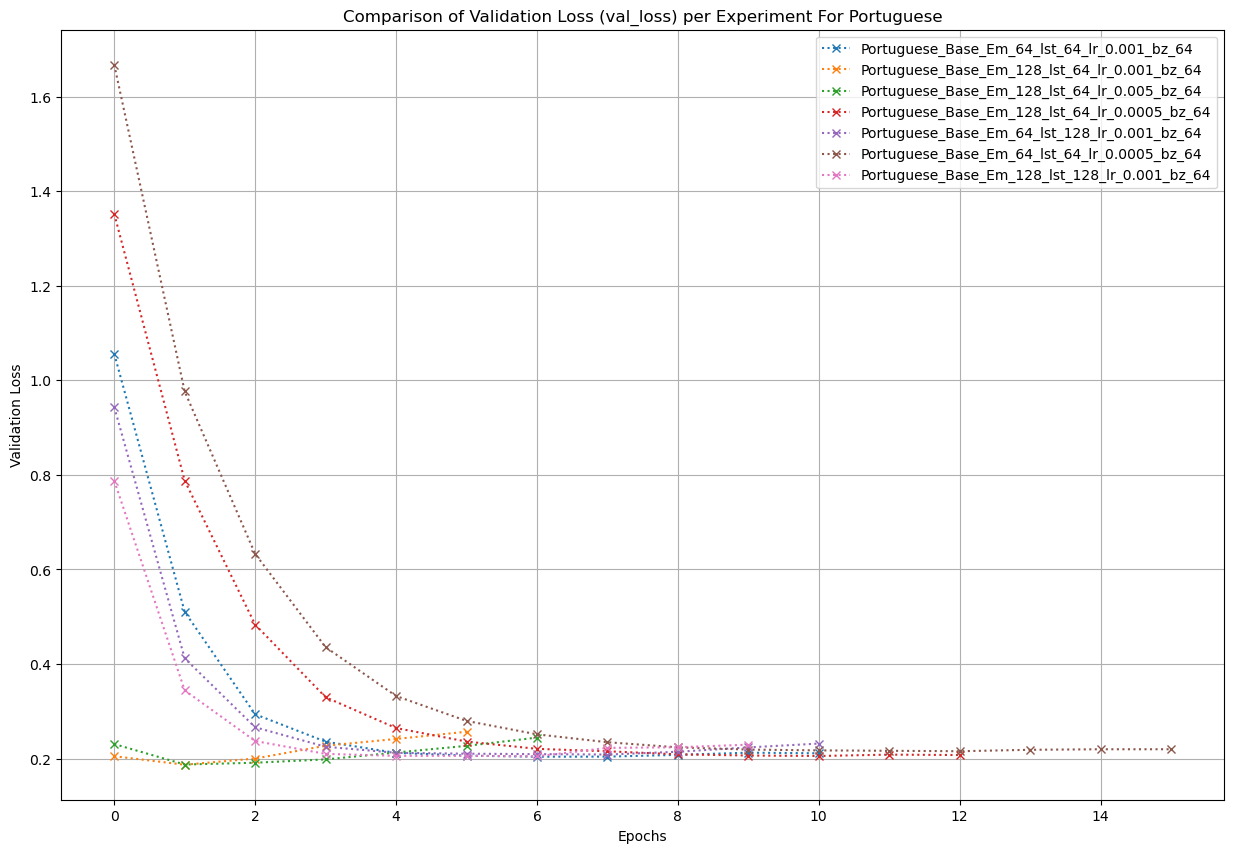

In [51]:
import matplotlib.pyplot as plt

# Plot Validation Accuracy 
plt.figure(figsize=(15, 10))
plt.title("Comparison of Validation Accuracy (val_accuracy) per Experiment For Portuguese")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

for model_name_portuguese, history_data_portuguese in all_histories_portuguese.items():
    plt.plot(history_data_portuguese['val_accuracy'], label=model_name_portuguese, marker='o', linestyle='--')

plt.legend() 
plt.grid(True)
plt.show()   

# --- Plot Validation Loss ---
plt.figure(figsize=(15, 10))
plt.title("Comparison of Validation Loss (val_loss) per Experiment For Portuguese")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")

for model_name_portuguese, history_data_portuguese in all_histories_portuguese.items():
    plt.plot(history_data_portuguese['val_loss'], label=model_name_portuguese, marker='x', linestyle=':')

plt.legend() 
plt.grid(True)  
plt.show()    

## Now with Persian (Farsi)

Now we are make the Training for farsi data .


In [53]:

SELECTED_LANGUAGE_FA = 'fa' 

try:
    paths = LANGUAGE_CONFIG[SELECTED_LANGUAGE_FA]
    print(f"--- Model for: '{SELECTED_LANGUAGE_FA}' ---")

    train_sents_persian, train_tags_persian = load_conllu_data(paths['train'])
    dev_sents_persian, dev_tags_persian = load_conllu_data(paths['dev'])
    test_sents_persian, test_tags_persian = load_conllu_data(paths['test'])
    
    print("\nLoading complete")
    print(f"Sentences for training: {len(train_sents_persian)}")
    print(f"Sentences for dev: {len(dev_sents_persian)}")
    print(f"Sentences for test: {len(test_sents_persian)}")
    
except KeyError:
    print(f"Error: The language '{SELECTED_LANGUAGE_FA}' is not in LANGUAGE_CONFIG.")

word_vectorizer_persian, WORD_VOCAB_SIZE_PERSIAN = create_and_adapt_vectorizer(
    train_sents_persian, 
    standardize="lower_and_strip_punctuation" 
)

tags_vectorizer_persian, TAGS_VOCAB_SIZE_PERSIAN = create_and_adapt_vectorizer(
    train_tags_persian, 
    standardize=None
)

tags_vocab_list_persian = tags_vectorizer_persian.get_vocabulary()
print("tags_vectorizer_persian", tags_vocab_list_persian)

print(f"\nWe have successfully created a vectorizer with a vocabulary of {WORD_VOCAB_SIZE_PERSIAN} words.")
print(f"\nWe have successfully created a vectorizer with a vocabulary of {TAGS_VOCAB_SIZE_PERSIAN} tags.")


print("Vectorizing all data sets...")

train_sents_flat_persian = [' '.join(sentence) for sentence in train_sents_persian]
train_tags_flat_persian = [' '.join(tag_list) for tag_list in train_tags_persian]

dev_sents_flat_persian = [' '.join(sentence) for sentence in dev_sents_persian]
dev_tags_flat_persian = [' '.join(tag_list) for tag_list in dev_tags_persian]

test_sents_flat_persian = [' '.join(sentence) for sentence in test_sents_persian]
test_tags_flat_persian = [' '.join(tag_list) for tag_list in test_tags_persian]

X_train_persian = word_vectorizer_persian(train_sents_flat_persian)
y_train_persian = tags_vectorizer_persian(train_tags_flat_persian)

X_dev_persian = word_vectorizer_persian(dev_sents_flat_persian)
y_dev_persian = tags_vectorizer_persian(dev_tags_flat_persian)

X_test_persian = word_vectorizer_persian(test_sents_flat_persian)
y_test_persian = tags_vectorizer_persian(test_tags_flat_persian)

hyperparameter_grid_persian = [
    {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_64_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 32,
        "model_name": "Persian_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
     {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 128,
        "model_name": "Persian_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.005,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_128_lst_64_lr_0.005_bz_64"
    },
        {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.01,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_128_lst_64_lr_0.001_bz_64"
    },
          {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_128_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 64,
        "lstm_units": 128,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_64_lst_128_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Persian_Base_Em_64_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "model_name": "Persian_Base_Em_128_lst_128_lr_0.001_bz_64"
    },
    
]


all_histories_persian = {} 
best_val_accuracy_persian = -1.0
best_model_persian = None
best_model_name_persian = ""

print("\n--- Starting PERSIAN Model Experimentation Loop ---")

for params in hyperparameter_grid_persian:
    
    model_persian, history_persian = build_and_train_model(
        WORD_VOCAB_SIZE_PERSIAN, TAGS_VOCAB_SIZE_PERSIAN, MAX_LEN,
        X_train_persian, y_train_persian, X_dev_persian, y_dev_persian,
        embedding_dim=params["embedding_dim"],
        lstm_units=params["lstm_units"],
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        epochs=EPOCHS, 
        model_name=params["model_name"]
    )
    
    all_histories_persian[params["model_name"]] = history_persian.history
    
    current_best_val_acc_persian = max(history_persian.history['val_accuracy'])
    
    print(f"\nModel {params['model_name']} finished with best val_accuracy: {current_best_val_acc_persian:.4f}")
    
    if current_best_val_acc_persian > best_val_accuracy_persian:
        print(f"¡This is the new BEST PERSIAN model! Name: {params['model_name']} with {current_best_val_acc_persian:.4f} val_accuracy")
        best_val_accuracy_persian = current_best_val_acc_persian
        best_model_persian = model_persian
        best_model_name_persian = params["model_name"]
        
print(f"\n--- Persian experimentation finished ---")
print(f"The best Persian model was '{best_model_name_persian}' with val_accuracy {best_val_accuracy_persian*100:.2f}%")

if best_model_persian:
    save_filename_persian = f"{best_model_name_persian}_best.keras"
    print(f"\nSaving the best overall Persian model to: {save_filename_persian}")
    best_model_persian.save(save_filename_persian)
    print(f"Model saved successfully to '{save_filename_persian}'")
else:
    print("No best Persian model was found or saved.")

--- Model for: 'fa' ---

Loading complete
Sentences for training: 26196
Sentences for dev: 1456
Sentences for test: 1455

Sentences before flat ['در', 'ابتدای', 'این', 'مانور', 'آزمایشی', 'نشست', 'و', 'برخاست', 'هلی\u200cکوپتر', 'و', 'عملیات', 'راپل', '(', 'پیاده', 'کردن', 'تکاورهای', 'ویژه', ')', 'اجرا', 'شد', '.']

Sentence after flat در ابتدای این مانور آزمایشی نشست و برخاست هلی‌کوپتر و عملیات راپل ( پیاده کردن تکاورهای ویژه ) اجرا شد .

Adaptation complete. Vocabulary size: 31964

Sentences before flat ['ADP', 'NOUN', 'DET', 'NOUN', 'ADJ', 'NOUN', 'CCONJ', 'NOUN', 'NOUN', 'CCONJ', 'NOUN', 'NOUN', 'PUNCT', 'ADJ', 'NOUN', 'NOUN', 'ADJ', 'PUNCT', 'NOUN', 'VERB', 'PUNCT']

Sentence after flat ADP NOUN DET NOUN ADJ NOUN CCONJ NOUN NOUN CCONJ NOUN NOUN PUNCT ADJ NOUN NOUN ADJ PUNCT NOUN VERB PUNCT

Adaptation complete. Vocabulary size: 18
tags_vectorizer_persian ['', '[UNK]', np.str_('NOUN'), np.str_('ADP'), np.str_('VERB'), np.str_('PUNCT'), np.str_('ADJ'), np.str_('PRON'), np.str_('PRO

Model: "Persian_Base_Em_64_lst_64_lr_0.001_bz_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  2,045,696 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_70        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_70    │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_70[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 18)   │      2,322 │ bidirectional_70… │
│ (TimeDistributed)   │                   │            │ not_equal_70[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,114,066 (8.06 MB)

 Trainable params: 2,114,066 (8.06 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  4,091,392 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_79        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_79    │ (None, 128, 256)  │    263,168 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_79[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 18)   │      4,626 │ bidirectional_79… │
│ (TimeDistributed)   │                   │            │ not_equal_79[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,359,186 (16.63 MB)

 Trainable params: 4,359,186 (16.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 103ms/step - accuracy: 0.7638 - loss: 0.8736 - val_accuracy: 0.8775 - val_loss: 0.4363
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.9100 - loss: 0.3430 - val_accuracy: 0.8906 - val_loss: 0.3754
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.9258 - loss: 0.2590 - val_accuracy: 0.8963 - val_loss: 0.3631
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.9379 - loss: 0.2043 - val_accuracy: 0.8979 - val_loss: 0.3730
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.9472 - loss: 0.1680 - val_accuracy: 0.8959 - val_loss: 0.4077
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.9558 - loss: 0.1386 - val_accuracy: 0.8950 - val_loss: 0.4000
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.9628 - loss: 0.1160 - val_accuracy: 0.8926 - val_loss: 0.4131
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
--- 

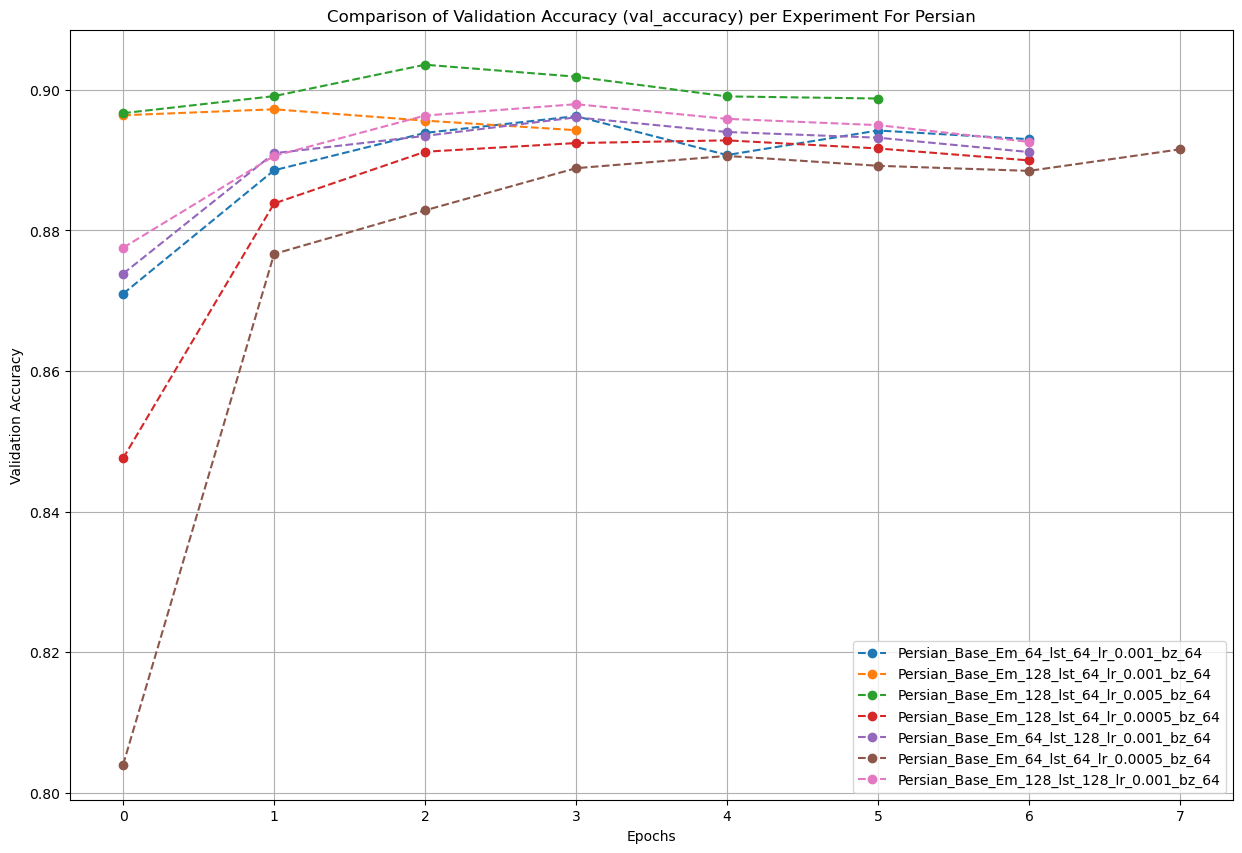

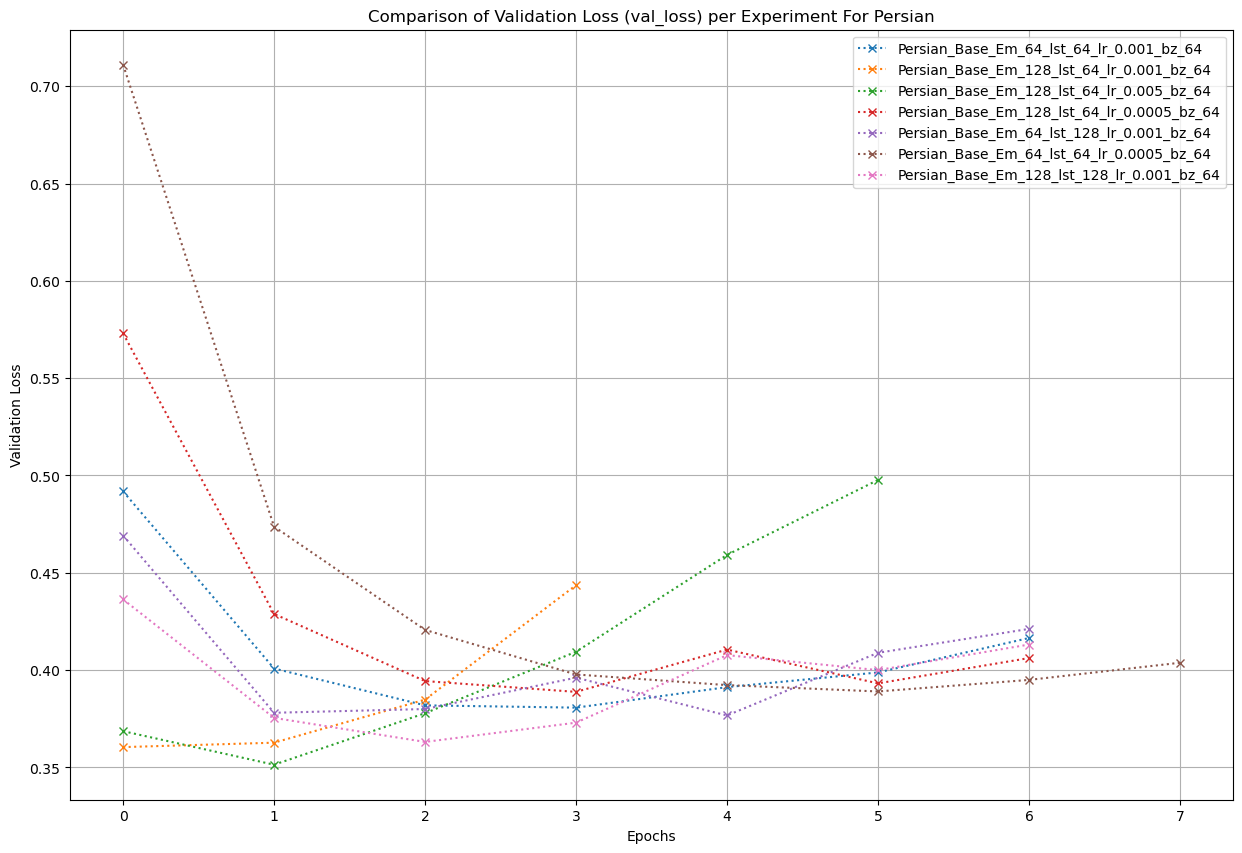

In [54]:
# Plot Validation Accuracy 
plt.figure(figsize=(15, 10))
plt.title("Comparison of Validation Accuracy (val_accuracy) per Experiment For Persian")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

for model_name_persian, history_data_persian in all_histories_persian.items():
    plt.plot(history_data_persian['val_accuracy'], label=model_name_persian, marker='o', linestyle='--')

plt.legend() 
plt.grid(True)
plt.show()   

# --- Plot Validation Loss ---
plt.figure(figsize=(15, 10))
plt.title("Comparison of Validation Loss (val_loss) per Experiment For Persian")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")

for model_name_persian, history_data_persian in all_histories_persian.items():
    plt.plot(history_data_persian['val_loss'], label=model_name_persian, marker='x', linestyle=':')

plt.legend() 
plt.grid(True)  
plt.show()    






## Predicting on New Sentences

The final step is to use the trained model to tag completely new sentences.

#### Code Explanation: `predict_tags` Function

This cell defines a utility function `predict_tags` that encapsulates the entire prediction pipeline.

* **Purpose**: To take a sentence as a string, process it, and display the model's predictions word by word.
* **Steps**:
    1.  **Vectorize**: It takes the `sentence_string` and passes it to the `word_vectorizer` (which is already "adapted" or trained). The vectorizer lowercases it, tokenizes it, and transforms it into a padded ID tensor of length 128 (shape `[1, 128]`).
    2.  **Predict**: It calls `model.predict()` with that tensor. The model returns a tensor of probabilities with shape `[1, 128, 18]` (Batch, SeqLen, NumTags).
    3.  **`argmax`**: `np.argmax(predictions, axis=-1)` is applied on the last axis (the tag axis). For each of the 128 positions, it finds the *index* (the tag ID, from 0 to 17) that had the highest probability. The `[0]` at the end removes the batch dimension, leaving an array of shape `[128,]`.
    4.  **Decode**: The code gets the tag vocabulary (the list of strings, e.g., `['', '[UNK]', 'noun', ... ]`) from the `tags_vectorizer`.
    5.  **Display**: It iterates over the words from the original sentence (split by spaces) and uses the `predicted_ids` to look up the corresponding tag name in the `tags_vocab`.

In [33]:
import numpy as np


# 1. Get the tag vocabulary (the list of strings)
# ID 0 is '', ID 1 is '[UNK]', so the real vocabulary starts at index 2
tags_vocab = tags_vectorizer.get_vocabulary()

def predict_tags(sentence_string):
    """
    Takes a sentence (string), processes it with the model,
    and displays the predictions word by word.
    """
    print(f"--- Predicting for: ---\n{sentence_string}\n")
    
    # 0. Split the words to know how many there are
    words = sentence_string.split(' ')
    
    # 1. Convert the sentence (string) into an ID tensor (shape [1, 128])
    # The vectorizer expects a list of strings
    input_tensor = word_vectorizer([sentence_string])
    print("input_tensor",input_tensor)
    
    # 2. Get the model's predictions
    # The model returns probabilities (shape [1, 128, 18])
    predictions = model.predict(input_tensor)
    
    # 3. Find the ID of the tag with the highest probability for each token
    # We use np.argmax to get the winning IDs (shape [1, 128])
    predicted_ids = np.argmax(predictions, axis=-1)[0] # [0] to get the first (and only) batch
    print("predicted_ids",predicted_ids)
    
    # 4. Display the results
    print("--- Results: ---")
    for i in range(len(words)):
        word = words[i]
        tag_id = predicted_ids[i]
        tag_name = tags_vocab[tag_id]
        
        print(f"{word:<15} -> {tag_name}")

#### Code Explanation: Testing on New Sentences

This final cell puts everything together.

* **`new_test_sentences`**: A dictionary that stores lists of test sentences for each language.
* **Language Selection**: The code checks the `SELECTED_LANGUAGE` variable.
* **Prediction**: The `if` statement finds the key in the dictionary and then iterates over the list of sentences, calling `predict_tags` for each one.
* **Output**: The output shows the predictions for each test sentence.

In [18]:
# 1. Get the tag vocabulary
tags_vocab = tags_vectorizer.get_vocabulary()

# 2. Define the test sentences in a dictionary
new_test_sentences = {
    'en': [
        "Google is a nice search engine.",
        "I am writing this new sentence for the test.",
        "The university is in santiago.",
        "This model should tag punctuation correctly."
    ],
    'es': [
        "La universidad está en Santiago.",
        "Estoy escribiendo una nueva frase para la prueba.",
        "Google es un buen motor de búsqueda.",
        "telescopio comer", 
        "Este modelo debería etiquetar la puntuación correctamente."
    ],
    'pt': [
        "Lisboa é a capital de Portugal.",
        "Eu estou escrevendo uma nova frase para o teste.",
        "Onde fica a estação de trem mais próxima?",
        "Este modelo funciona corretamente.",
    ],
    'fa': [
        "دانشگاه در تهران است", # The university is in Tehran
        "من در حال نوشتن یک جمله جدید هستم", # I am writing a new sentence
        "این یک آزمایش برای مدل است", # This is a test for the model
    ],
    
}

# 3. Select and test the sentences for the chosen language
if SELECTED_LANGUAGE in new_test_sentences:
    for sent in new_test_sentences[SELECTED_LANGUAGE]:
        predict_tags(sent)
else:
    print(f"No example sentences found for '{SELECTED_LANGUAGE}'.")

print("\n--- Process Complete ---")




--- Predicting for: ---
La universidad está en Santiago.

input_tensor tf.Tensor(
[[  5 711  54   8   1   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]], shape=(1, 128), dtype=int64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted_ids [ 4  2 12  3  2  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8 